In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv')

In [ ]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
print('Rows:',df.shape[0])
print('Columns:',df.shape[1])
print()

print('Features')
print()
print( df.columns.tolist())
print()

print(' Unique Values')
print()
print( df.nunique())

Rows: 150
Columns: 5

Features

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

 Unique Values

sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64


In [ ]:
df.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

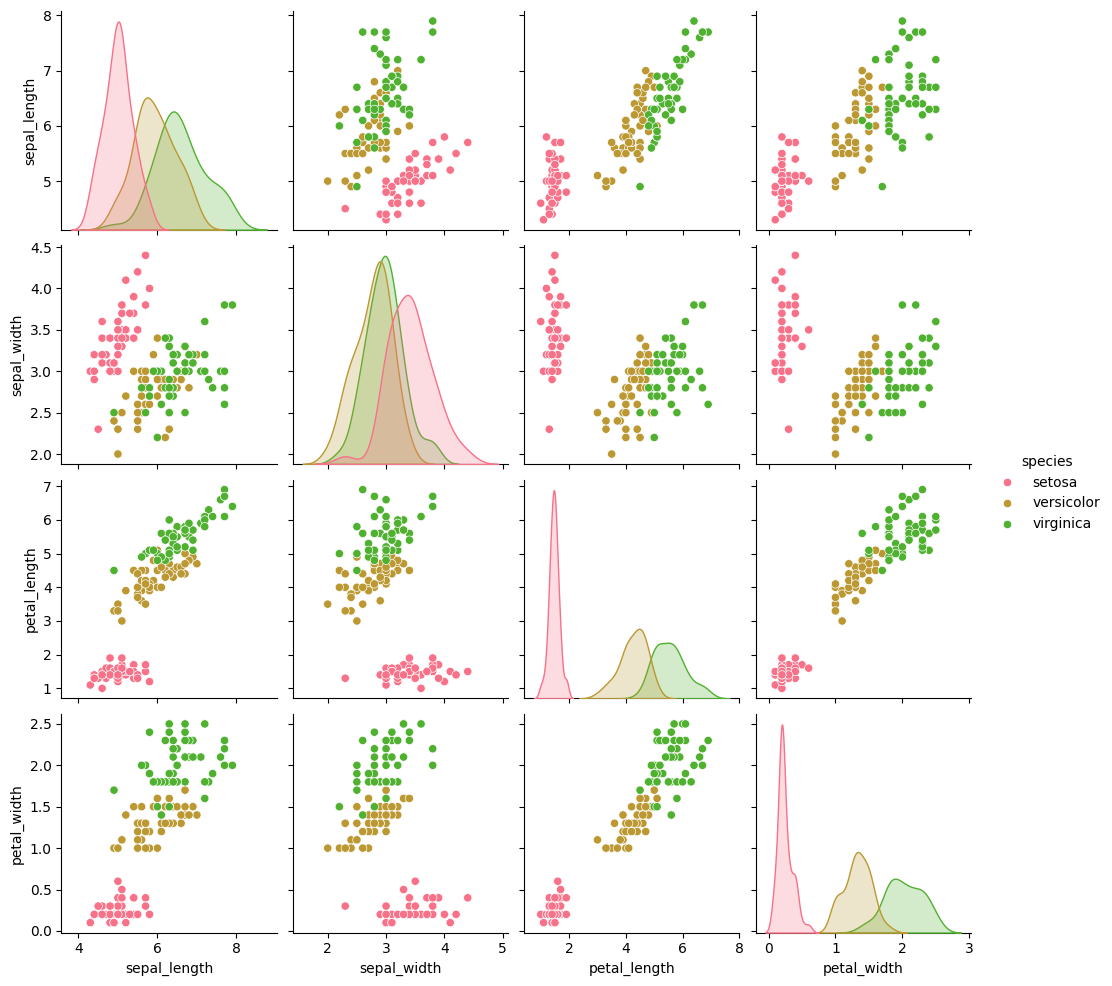

In [ ]:
sns.pairplot(df, hue='species')
plt.show()

In [ ]:
X = df[
    ['sepal_length',
     'sepal_width',
     'petal_length',
     'petal_width']
].values

y = (df['species'] != 'setosa').astype(int).values

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 10 labels:")
print(y[:10])

X shape: (150, 4)
y shape: (150,)

First 10 labels:
[0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def tanh_probability(z):
    return (np.tanh(z) + 1) / 2

In [ ]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

In [ ]:
class LogisticRegressionCustom:

    def __init__(
        self,
        learning_rate=0.01,
        epochs=1000,
        activation='sigmoid',
        regularization=None,
        lambda_reg=0.01
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.activation = activation
        self.regularization = regularization
        self.lambda_reg = lambda_reg

        self.weights = None
        self.bias = None
        self.loss_history = []


    def activation_function(self, z):
        if self.activation == 'sigmoid':
            return sigmoid(z)

        elif self.activation == 'tanh':
            return tanh_probability(z)

        else:
            raise ValueError("Activation must be sigmoid or tanh")


    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        self.loss_history = []

        for epoch in range(self.epochs):

            z = np.dot(X, self.weights) + self.bias

            y_pred = self.activation_function(z)

            loss = cross_entropy_loss(y, y_pred)

            if self.regularization == 'l2':
                loss += self.lambda_reg * np.sum(self.weights ** 2)

            elif self.regularization == 'l1':
                loss += self.lambda_reg * np.sum(np.abs(self.weights))

            self.loss_history.append(loss)

            error = y_pred - y

            dw = np.dot(X.T, error) / n_samples
            db = np.mean(error)

            if self.regularization == 'l2':
                dw += 2 * self.lambda_reg * self.weights

            elif self.regularization == 'l1':
                dw += self.lambda_reg * np.sign(self.weights)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db


    def predict_proba(self, X):

        z = np.dot(X, self.weights) + self.bias

        return self.activation_function(z)


    def predict(self, X):

        probabilities = self.predict_proba(X)

        return (probabilities >= 0.5).astype(int)

In [ ]:
vanilla_model = LogisticRegressionCustom(
    learning_rate=0.01,
    epochs=2000,
    activation='sigmoid',
    regularization=None
)

vanilla_model.fit(X_train, y_train)

y_pred = vanilla_model.predict(X_test)

accuracy = np.mean(y_pred == y_test)

print("Vanilla Logistic Regression")
print("Accuracy:", accuracy)
print("Weights:", vanilla_model.weights)
print("Bias:", vanilla_model.bias)

Vanilla Logistic Regression
Accuracy: 1.0
Weights: [ 0.8432978  -1.12819945  1.30864651  1.22219264]
Bias: 1.1222806346394778


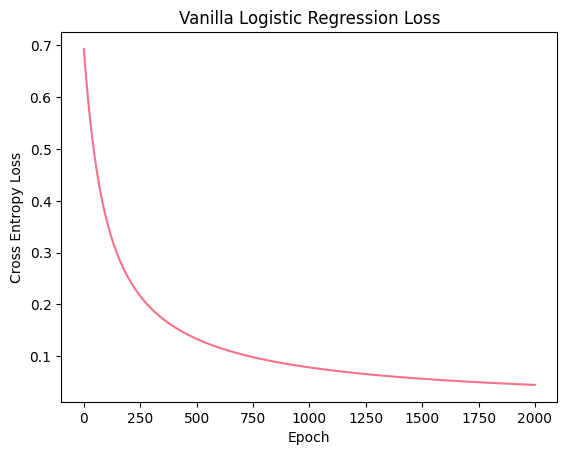

In [ ]:
plt.plot(vanilla_model.loss_history)

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Vanilla Logistic Regression Loss")

plt.show()

In [ ]:
sigmoid_model = LogisticRegressionCustom(
    learning_rate=0.01,
    epochs=2000,
    activation='sigmoid'
)

sigmoid_model.fit(X_train, y_train)

sigmoid_pred = sigmoid_model.predict(X_test)

sigmoid_accuracy = np.mean(sigmoid_pred == y_test)

print("Sigmoid Logistic Regression")
print("Accuracy:", sigmoid_accuracy)

Sigmoid Logistic Regression
Accuracy: 1.0


In [ ]:
tanh_model = LogisticRegressionCustom(
    learning_rate=0.01,
    epochs=2000,
    activation='tanh'
)

tanh_model.fit(X_train, y_train)

tanh_pred = tanh_model.predict(X_test)

tanh_accuracy = np.mean(tanh_pred == y_test)

print("Tanh Logistic Regression")
print("Accuracy:", tanh_accuracy)

Tanh Logistic Regression
Accuracy: 1.0


In [ ]:
print("Sigmoid Accuracy:", sigmoid_accuracy)
print("Tanh Accuracy:", tanh_accuracy)

Sigmoid Accuracy: 1.0
Tanh Accuracy: 1.0


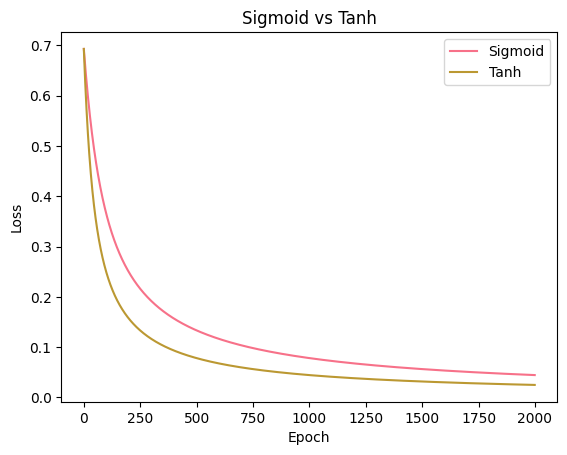

In [ ]:
plt.plot(
    sigmoid_model.loss_history,
    label='Sigmoid'
)

plt.plot(
    tanh_model.loss_history,
    label='Tanh'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sigmoid vs Tanh")

plt.legend()
plt.show()

In [ ]:
ridge_sigmoid = LogisticRegressionCustom(
    learning_rate=0.01,
    epochs=2000,
    activation='sigmoid',
    regularization='l2',
    lambda_reg=0.01
)

ridge_sigmoid.fit(X_train, y_train)

ridge_sigmoid_pred = ridge_sigmoid.predict(X_test)

ridge_sigmoid_accuracy = np.mean(
    ridge_sigmoid_pred == y_test
)

print("Ridge Logistic Regression - Sigmoid")
print("Accuracy:", ridge_sigmoid_accuracy)
print("Weights:", ridge_sigmoid.weights)

Ridge Logistic Regression - Sigmoid
Accuracy: 1.0
Weights: [ 0.7339541  -0.9399793   1.12279248  1.04907942]


In [ ]:
ridge_tanh = LogisticRegressionCustom(
    learning_rate=0.01,
    epochs=2000,
    activation='tanh',
    regularization='l2',
    lambda_reg=0.01
)

ridge_tanh.fit(X_train, y_train)

ridge_tanh_pred = ridge_tanh.predict(X_test)

ridge_tanh_accuracy = np.mean(
    ridge_tanh_pred == y_test
)

print("Ridge Logistic Regression - Tanh")
print("Accuracy:", ridge_tanh_accuracy)
print("Weights:", ridge_tanh.weights)

Ridge Logistic Regression - Tanh
Accuracy: 1.0
Weights: [ 0.43229315 -0.58274234  0.68623458  0.63681276]


In [ ]:
lasso_sigmoid = LogisticRegressionCustom(
    learning_rate=0.01,
    epochs=2000,
    activation='sigmoid',
    regularization='l1',
    lambda_reg=0.01
)

lasso_sigmoid.fit(X_train, y_train)

lasso_sigmoid_pred = lasso_sigmoid.predict(X_test)

lasso_sigmoid_accuracy = np.mean(
    lasso_sigmoid_pred == y_test
)

print("LASSO Logistic Regression - Sigmoid")
print("Accuracy:", lasso_sigmoid_accuracy)
print("Weights:", lasso_sigmoid.weights)

LASSO Logistic Regression - Sigmoid
Accuracy: 1.0
Weights: [ 0.73797564 -1.00125231  1.22585349  1.13253654]


In [ ]:
lasso_tanh = LogisticRegressionCustom(
    learning_rate=0.01,
    epochs=2000,
    activation='tanh',
    regularization='l1',
    lambda_reg=0.01
)

lasso_tanh.fit(X_train, y_train)

lasso_tanh_pred = lasso_tanh.predict(X_test)

lasso_tanh_accuracy = np.mean(
    lasso_tanh_pred == y_test
)

print("LASSO Logistic Regression - Tanh")
print("Accuracy:", lasso_tanh_accuracy)
print("Weights:", lasso_tanh.weights)

LASSO Logistic Regression - Tanh
Accuracy: 1.0
Weights: [ 0.39372747 -0.58098483  0.72362137  0.65764671]


In [ ]:
vanilla_accuracy = np.mean(
    vanilla_model.predict(X_test) == y_test
)

results = pd.DataFrame({
    'Model': [
        'Vanilla Sigmoid',
        'Sigmoid',
        'Tanh',
        'Ridge Sigmoid',
        'Ridge Tanh',
        'LASSO Sigmoid',
        'LASSO Tanh'
    ],

    'Accuracy': [
        vanilla_accuracy,
        sigmoid_accuracy,
        tanh_accuracy,
        ridge_sigmoid_accuracy,
        ridge_tanh_accuracy,
        lasso_sigmoid_accuracy,
        lasso_tanh_accuracy
    ]
})

print(results)

             Model  Accuracy
0  Vanilla Sigmoid       1.0
1          Sigmoid       1.0
2             Tanh       1.0
3    Ridge Sigmoid       1.0
4       Ridge Tanh       1.0
5    LASSO Sigmoid       1.0
6       LASSO Tanh       1.0


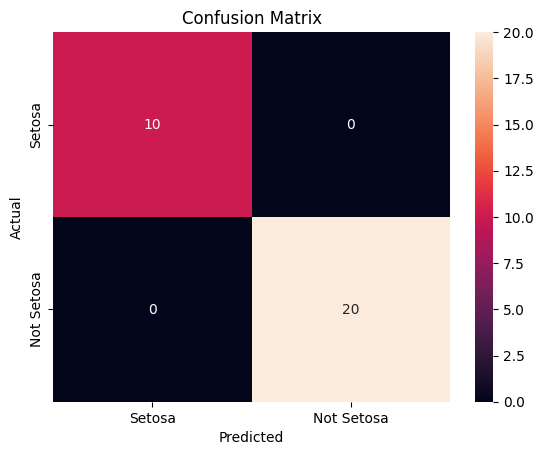

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(
    y_test,
    sigmoid_model.predict(X_test)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Setosa', 'Not Setosa'],
    yticklabels=['Setosa', 'Not Setosa']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        sigmoid_model.predict(X_test),
        target_names=['Setosa', 'Not Setosa']
    )
)

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Not Setosa       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

